In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn

device = torch.device('cuda')
seed = 420
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed) # If using Kaggle GPUs
np.random.seed(seed)
random.seed(seed)

# Force PyTorch to use deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
train_path = '/kaggle/input/datasets/kanishbkhagat/cic-ddos-cleaned/cic_ddos_cleaned_top20.parquet'
test_path = '/kaggle/input/datasets/kanishbkhagat/cic-ddos-cleaned/cic_ddos_cleaned_top20_test.parquet'

train = pl.read_parquet(train_path)
#test = pl.read_parquet(test_path)

In [3]:
train = train.filter(pl.col('Target') == 1)
train = train.select(pl.all().cast(pl.Float64, strict = False)).drop(['Label', 'Target']).to_numpy()
train[np.isinf(train)] = np.nan
train = np.nan_to_num(train, nan = 0.0)

scaler = StandardScaler()
train = scaler.fit_transform(train)
train = torch.FloatTensor(train)

In [4]:
class AutoEncoder(nn.Module):
    
    def __init__(self, input_dim):
        super().__init__()
        
        self.encoder = nn.Sequential(
                        nn.Linear(input_dim, 14),
                        nn.ReLU(),
                        nn.Linear(14, 8),
                        nn.ReLU(),
                        nn.Linear(8, 4),
                        nn.ReLU())
        
        self.decoder = nn.Sequential(
                        nn.Linear(4, 8),
                        nn.ReLU(),
                        nn.Linear(8, 14),
                        nn.ReLU(),
                        nn.Linear(14, input_dim))
        
    def forward(self, x):
        
        x = self.encoder(x)
        return self.decoder(x)

In [5]:
input_dim = train.shape[1]
model = AutoEncoder(input_dim)
model = nn.DataParallel(model).to(device)
batch_size = 2048
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', 0.5, 20,)
epochs = 5000

In [6]:
dataset = TensorDataset(train, train)
dataset = DataLoader(dataset, batch_size = 2048, shuffle = True) 

In [7]:
print('Trainig Started')
history = []
patience = 50
min_delta = 0.0001
best_loss = float('inf')
counter = 0
model_save_path = '/kaggle/working/best_ddos_autoencoder.pt'

for epoch in range(epochs):
    
    model.train()
    mse = 0.0
    
    for data, _ in dataset:
        data = data.to(device)
        
        optimizer.zero_grad()
        
        pred = model(data)
        loss = loss_fn(pred, data)
        
        loss.backward()
        optimizer.step()
        
        mse += loss.item()
        
    epoch_loss = mse / len(dataset)
    history.append(epoch_loss)   
    print(f'Epoch {epoch + 1}/{epochs}  | loss: {epoch_loss:.6f}')

    scheduler.step(epoch_loss)
    
    if epoch_loss < (best_loss - min_delta):
        best_loss = epoch_loss
        counter = 0
        print(f'Saving model to {model_save_path}')
        torch.save(model.state_dict(), model_save_path)

    else:
        counter += 1
        if counter > patience:
            print(f'Early Stopping at {epoch + 1} epoch')
            break

model.load_state_dict(torch.load(model_save_path))
print('Model Evaluation')
model.eval()
with torch.no_grad():
    train = train.to(device)
    mse_loss = torch.mean(torch.pow(train - model(train), 2), dim = 1)

threshold = np.percentile(mse_loss.cpu().numpy(), 99)
print('Threshold:', threshold)

Trainig Started


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


Epoch 1/5000  | loss: 1.020480
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 2/5000  | loss: 0.999302
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 3/5000  | loss: 0.968083
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 4/5000  | loss: 0.887867
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 5/5000  | loss: 0.749218
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 6/5000  | loss: 0.685217
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 7/5000  | loss: 0.665654
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 8/5000  | loss: 0.648587
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 9/5000  | loss: 0.634651
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 10/5000  | loss: 0.620766
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 11/5000  | loss: 0.611355
Saving model to /kaggle/working/best_ddos_autoencoder.pt
Epoch 12/5000  | loss: 0.58236

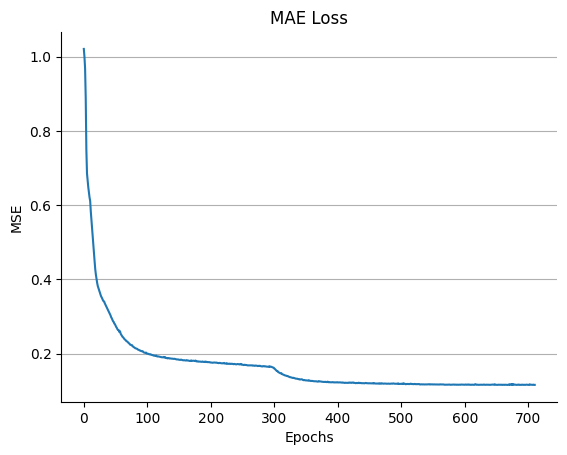

TypeError: imsave() missing 1 required positional argument: 'arr'

In [11]:
sns.lineplot(x = list(range(len(history))), y = history)
plt.title('MAE Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.grid(axis = 'y')
sns.despine()
plt.show()
plt.imsave('/kaggle/working/loss.png')

In [9]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']